In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:

# 1. Der absolute Basis-Pfad
base_dir = '/datasets/multi-view-pig-posture-recognition'

# 2. Pfade zu den Bild-Ordnern definieren
dir_train1 = os.path.join(base_dir, 'train1_images')
dir_train2 = os.path.join(base_dir, 'train2_images')
dir_test   = os.path.join(base_dir, 'test_images')

# 3. CSV-Dateien einlesen (auch hier den vollen Pfad nutzen)
# Wir gehen davon aus, dass die CSVs direkt im base_dir liegen
df_train1 = pd.read_csv(os.path.join(base_dir, 'train1.csv'))
df_train2 = pd.read_csv(os.path.join(base_dir, 'train2.csv'))
df_test   = pd.read_csv(os.path.join(base_dir, 'test.csv'))

In [4]:
filename_col = 'image_id'  

# 4. Pfade zu den Bildern in den DataFrames speichern
df_train1['path'] = df_train1[filename_col].apply(lambda x: os.path.join(dir_train1, x))
df_train2['path'] = df_train2[filename_col].apply(lambda x: os.path.join(dir_train2, x))
df_test['path']   = df_test[filename_col].apply(lambda x: os.path.join(dir_test, x))

# 5. Trainingsdaten zusammenfügen (Concatenate)
df_train_full = pd.concat([df_train1, df_train2], axis=0, ignore_index=True)

# Überprüfung
print(f"Pfad-Check (Erstes Bild): {df_train_full['path'].iloc[0]}")
print(f"Anzahl Trainingsbilder gesamt: {len(df_train_full)}")

Pfad-Check (Erstes Bild): /datasets/multi-view-pig-posture-recognition/train1_images/pen1_orb_cam1_20250108_085204.jpg
Anzahl Trainingsbilder gesamt: 46384


In [5]:
df_train_full.head(20)

,row_id,image_id,width,height,bbox,class_id,path
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0,/datasets/multi-view-pig-posture-recognition/t...
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4,/datasets/multi-view-pig-posture-recognition/t...
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1,/datasets/multi-view-pig-posture-recognition/t...
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0,/datasets/multi-view-pig-posture-recognition/t...
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3,/datasets/multi-view-pig-posture-recognition/t...
5,train_pen1_orb_cam1_20250108_085204_0005,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1023.4,261.6,340.6,192.4]",4,/datasets/multi-view-pig-posture-recognition/t...
6,train_pen1_orb_cam1_20250108_085204_0006,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[662.3,96.2,349.7,183.8]",1,/datasets/multi-view-pig-posture-recognition/t...
7,train_pen1_orb_cam1_20250108_085209_0000,pen1_orb_cam1_20250108_085209.jpg,1920,1080,"[1031.0,366.0,348.0,438.0]",0,/datasets/multi-view-pig-posture-recognition/t...
8,train_pen1_orb_cam1_20250108_085209_0001,pen1_orb_cam1_20250108_085209.jpg,1920,1080,"[800.5,169.0,397.0,267.0]",0,/datasets/multi-view-pig-posture-recognition/t...
9,train_pen1_orb_cam1_20250108_085209_0002,pen1_orb_cam1_20250108_085209.jpg,1920,1080,"[732.0,136.5,342.0,203.0]",1,/datasets/multi-view-pig-posture-recognition/t...


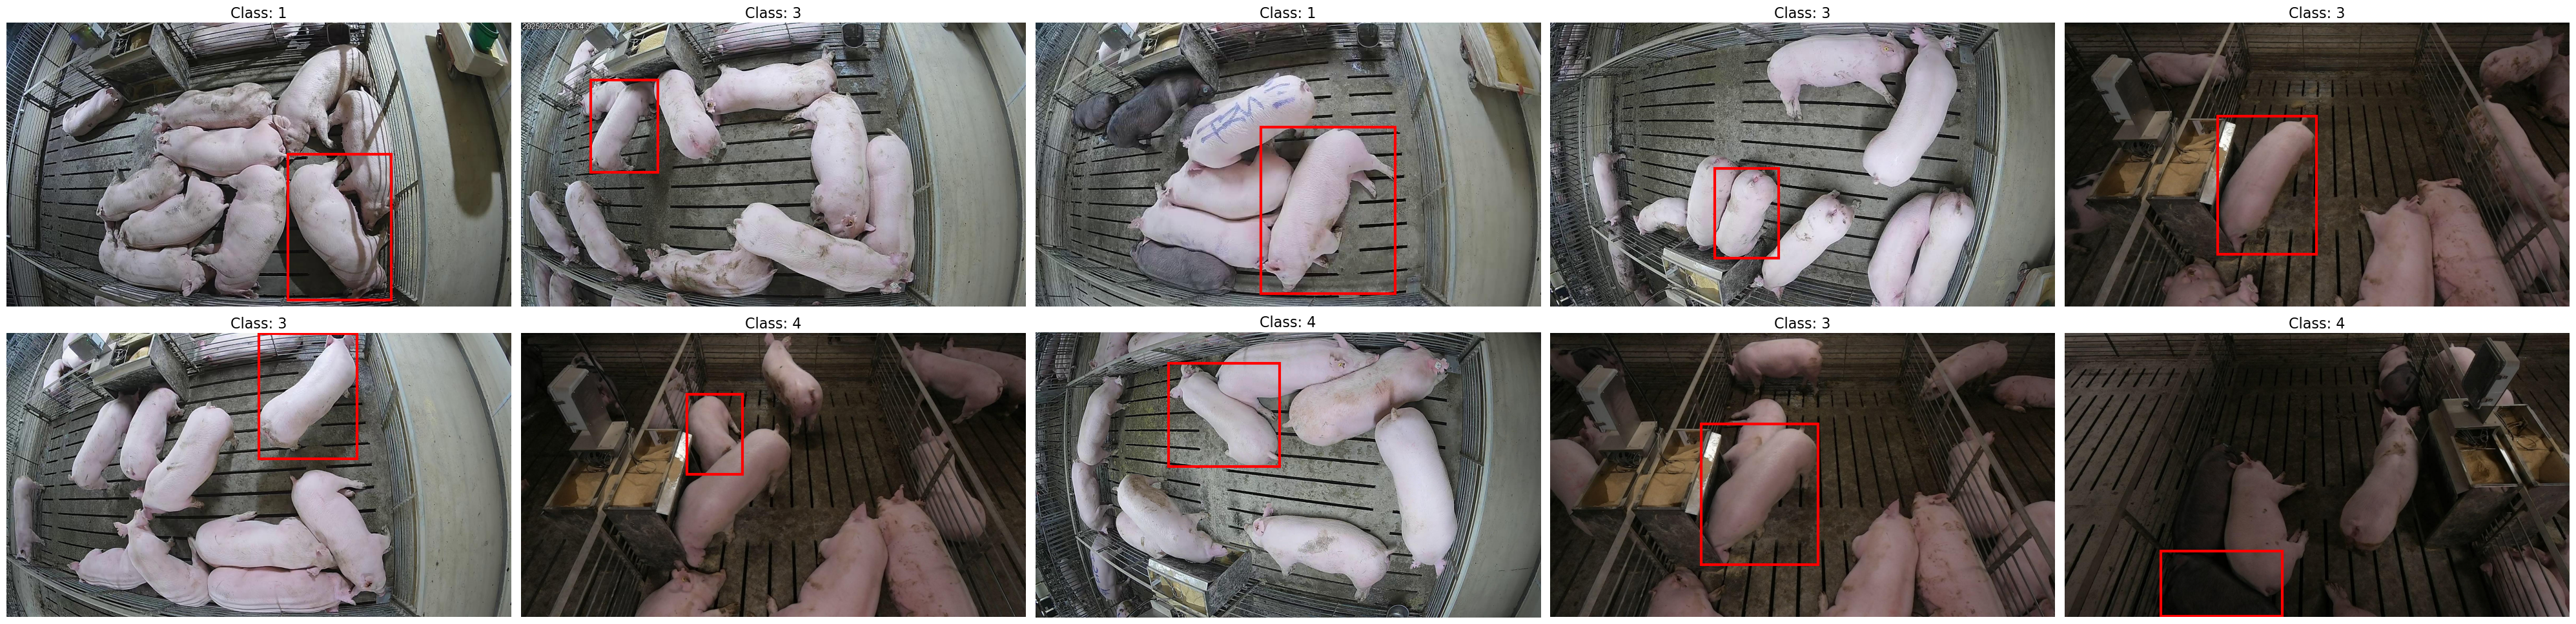

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import ast
import math

# 1. Wir nehmen diesmal 10 zufällige Bilder
samples = df_train_full.sample(n=10)

# 2. Raster erstellen: 2 Zeilen, 5 Spalten
# figsize=(25, 12) -> 25 Zoll breit, 12 Zoll hoch (sehr groß)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(40, 10))

# Wir müssen die Achsen "flachklopfen" (flatten), damit wir einfach durchiterieren können
axes = axes.flatten()

for i, (index, row) in enumerate(samples.iterrows()):
    # Wähle das passende Unter-Diagramm aus
    ax = axes[i]
    
    img_path = row['path']
    
    try:
        img = Image.open(img_path)
        ax.imshow(img)
        
        # --- Bounding Box Logik ---
        bbox_data = row['bbox']
        # String "[...]" in Liste umwandeln, falls nötig
        if isinstance(bbox_data, str):
            bbox = ast.literal_eval(bbox_data)
        else:
            bbox = bbox_data
            
        x, y, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
        
        # Rechteck
        rect = patches.Rectangle(
            (x, y), w, h, 
            linewidth=3,       # Dicke Linie
            edgecolor='red', 
            facecolor='none'
        )
        ax.add_patch(rect)
        
        # Label Schriftgröße erhöhen (fontsize=16)
        class_id = row.get('class_id', 'Unknown')
        ax.set_title(f"Class: {class_id}", fontsize=16)
        
    except Exception as e:
        print(f"Fehler bei Bild {i}: {e}")
        ax.text(0.5, 0.5, "Fehler", ha='center')

    # Achsen immer ausschalten (sieht sauberer aus)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
#check for nan
print("Überprüfung auf NaN-Werte in den DataFrames:")
print("Train1 DataFrame:", df_train1.isna().sum())
print("Train2 DataFrame:", df_train2.isna().sum())
print("Test DataFrame:", df_test.isna().sum())

Überprüfung auf NaN-Werte in den DataFrames:
Train1 DataFrame: row_id      0
image_id    0
width       0
height      0
bbox        0
class_id    0
path        0
dtype: int64
Train2 DataFrame: row_id      0
image_id    0
width       0
height      0
bbox        0
class_id    0
path        0
dtype: int64
Test DataFrame: row_id      0
image_id    0
width       0
height      0
bbox        0
path        0
dtype: int64


In [8]:
# Zähler auf 0 setzen
corrupted_count = 0

# Stille Schleife durch alle Bilder
for index, row in df_train_full.iterrows():
    img_path = row['path']
    
    try:
        # 1. Existiert die Datei?
        if not os.path.exists(img_path):
            corrupted_count += 1
            continue
            
        # 2. Ist sie lesbar?
        with Image.open(img_path) as img:
            img.verify() 
            
    except Exception:
        # Bei jedem Fehler (Datei fehlt oder kaputt) Zähler hochzählen
        corrupted_count += 1

# Einzige Ausgabe wie gewünscht
print(f"Anzahl korrupter Bilder: {corrupted_count}")

Anzahl korrupter Bilder: 0


In [9]:
# Idee --> zu überprüfen ob die Bilder in den verschiedenen Ordnern (train1, train2)
# unterschiedliche Perspektiven haben bzw. welche Perspektiven am meisten präsent sind


In [10]:
#ich will alle unique aus der image id
df_train_full['image_id'].unique()

array(['pen1_orb_cam1_20250108_085204.jpg',
       'pen1_orb_cam1_20250108_085209.jpg',
       'pen1_orb_cam1_20250108_085214.jpg', ...,
       'pen2_tur_cam2_20250120_082252.jpg',
       'pen2_tur_cam2_20250120_082433.jpg',
       'pen2_tur_cam2_20250120_082753.jpg'], dtype=object)

--- GEFUNDENE KAMERAS: 8 Stück ---
pen1_orb_cam1     1444
pen1_orb_cam2     2976
pen1_tur_cam1      200
pen1_tur_cam2    16388
pen2_orb_cam1     5634
pen2_orb_cam2      120
pen2_tur_cam1    19426
pen2_tur_cam2      196
Name: camera_id, dtype: int64


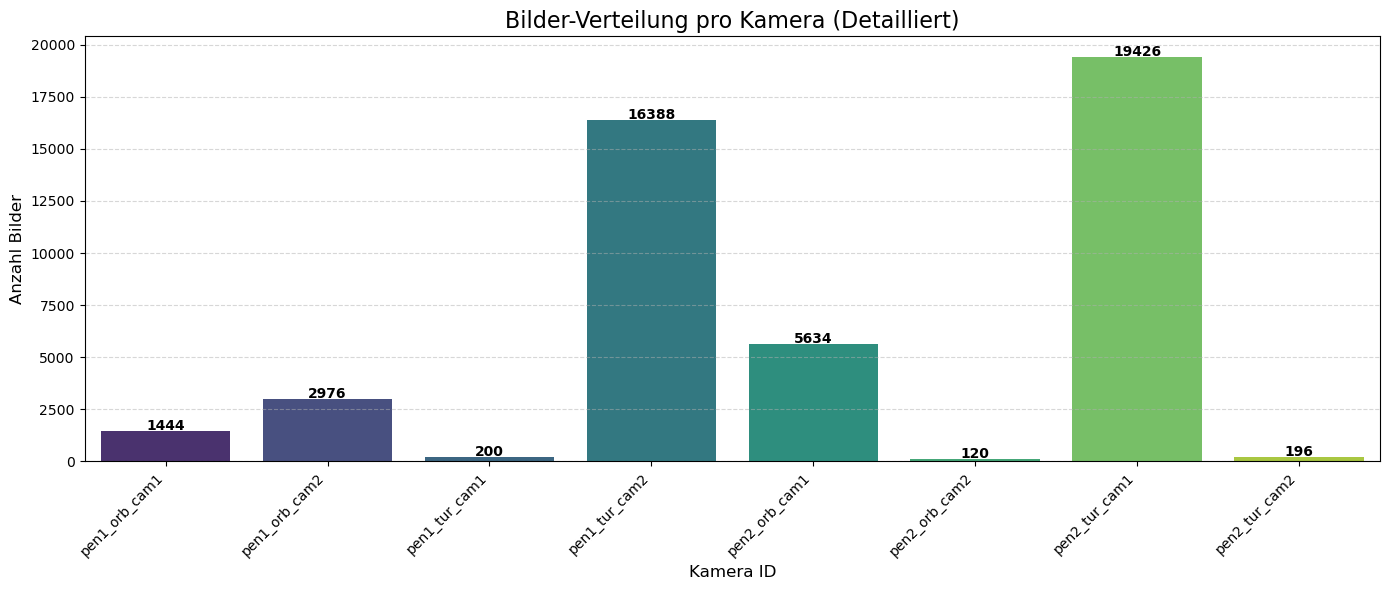

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

# 1. Kamera-Name extrahieren (penX_typ_camY)
# Das Regex sucht nach: "pen" + Zahl + "_" + Wort + "_" + "cam" + Zahl
# Beispiel: aus "train_pen1_orb_cam1_2025..." wird "pen1_orb_cam1"
def get_full_camera_name(image_id):
    match = re.search(r'(pen\d+_[a-zA-Z0-9]+_cam\d+)', str(image_id))
    if match:
        return match.group(1)
    return 'Unbekannt'

# Anwenden auf den DataFrame
df_train_full['camera_id'] = df_train_full['image_id'].apply(get_full_camera_name)

# 2. Zählen (Wir erwarten 8 verschiedene Kameras)
cam_counts = df_train_full['camera_id'].value_counts().sort_index()

print(f"--- GEFUNDENE KAMERAS: {len(cam_counts)} Stück ---")
print(cam_counts)

# 3. Balkendiagramm
plt.figure(figsize=(14, 6))
# 'viridis' ist gut, um Unterschiede deutlich zu machen
ax = sns.barplot(x=cam_counts.index, y=cam_counts.values, palette="viridis")

plt.title("Bilder-Verteilung pro Kamera (Detailliert)", fontsize=16)
plt.ylabel("Anzahl Bilder", fontsize=12)
plt.xlabel("Kamera ID", fontsize=12)

# Beschriftung schräg stellen, damit man 'pen1_orb_cam1' gut lesen kann
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Zahlen über die Balken schreiben
for i, v in enumerate(cam_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Wir prüfen auf exakte Übereinstimmung der 'image_id'.
# Das ignoriert Zeitstempel-Logik und schaut nur: Heißt das Bild exakt gleich?

# 1. Duplikate finden (markiert alle Vorkommen, die nicht das erste sind)
dupes = df_train_full.duplicated(subset=['image_id'], keep='first')

# 2. Anzahl zählen
anzahl_doppelte = dupes.sum()

print(f"Anzahl exakter Bild-Duplikate: {anzahl_doppelte}")

Anzahl exakter Bild-Duplikate: 43234


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import pandas as pd

# Einstellungen
BASE_DIR = '/datasets/multi-view-pig-posture-recognition'
NUM_IMAGES = 500         # Wir nehmen nur 500 Bilder zum Testen
BATCH_SIZE = 32          # 32 Bilder pro Schritt
NUM_EPOCHS = 5           # 3 Durchgänge reichen für den ersten Eindruck
LEARNING_RATE = 0.001

# Prüfen auf GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training läuft auf: {device}")

Training läuft auf: cuda
